# Exploratory data analysis
In this notebook, we will perform exploratory data analysis (EDA):
- Visualize the distribution of the target variable
- Show histogram of target variable to stratify the data
- Split the data into training and testing sets
- Replace month, day, and hour with datetime format
- Visualize the relationship between features and the target variable
- Analyze correlation
- Scale the features

In [137]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from numpy.ma.core import mean


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools import add_constant
from scipy import stats


In [129]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from utils.exploratory_data_analysis import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [101]:
df = pd.read_csv('../data/cleaned/bike_sharing.csv')
df.total_count.describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: total_count, dtype: float64

<Axes: xlabel='total_count', ylabel='Count'>

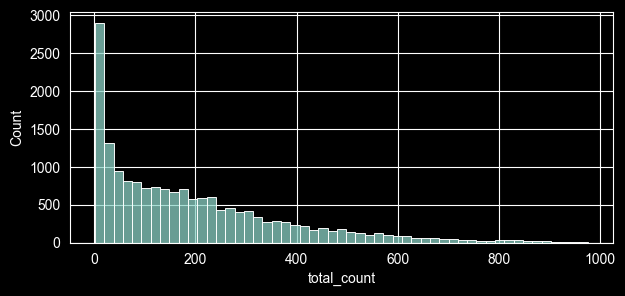

In [102]:
plt.figure(figsize=(7,3))
sns.histplot(df.total_count)

We can see that stratification is needed to split the data into training and testing sets, as the target variable is not uniformly distributed.

In [103]:
df['stratify_count'] = pd.cut(df["total_count"], 10, labels=list(range(1,11)))

In [104]:
print(df['stratify_count'].value_counts())

stratify_count
1     6972
2     3705
3     2659
4     1660
5      997
6      653
7      369
8      188
9      139
10      37
Name: count, dtype: int64


<Axes: xlabel='stratify_count', ylabel='Count'>

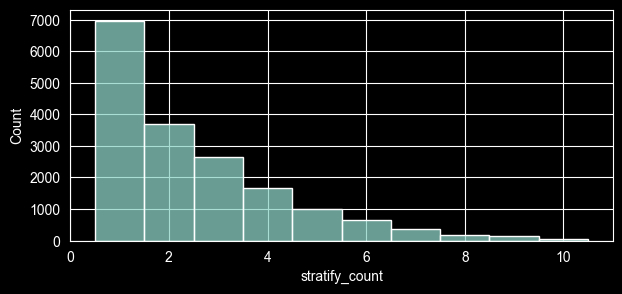

In [105]:
plt.figure(figsize=(7,3))
sns.histplot(df.stratify_count)

Train test split with stratification

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['total_count', 'stratify_count']),
    df['total_count'],
    test_size=0.2,
    random_state=42,
    stratify=df['stratify_count']
)
dftrain  = pd.concat([X_train, y_train], axis=1)

<Axes: >

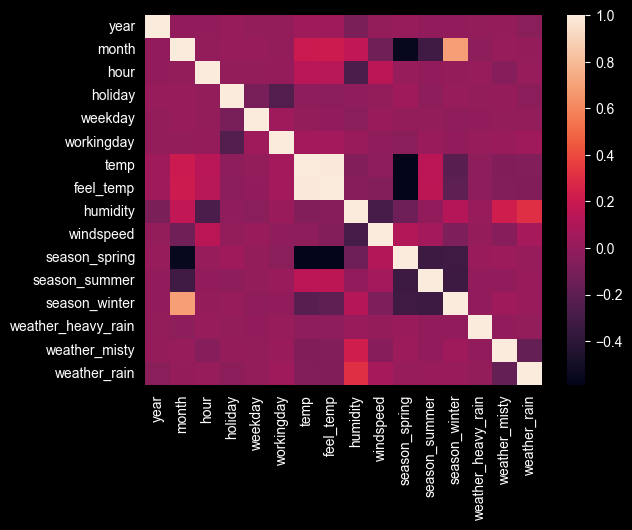

In [107]:
sns.heatmap(X_train.corr())

In [118]:
df = df.drop(columns=['season_spring', 'season_summer', 'season_winter'])

In [108]:
NUM_COLS = ["temp", "feel_temp", "humidity", "windspeed", "month", "hour"]

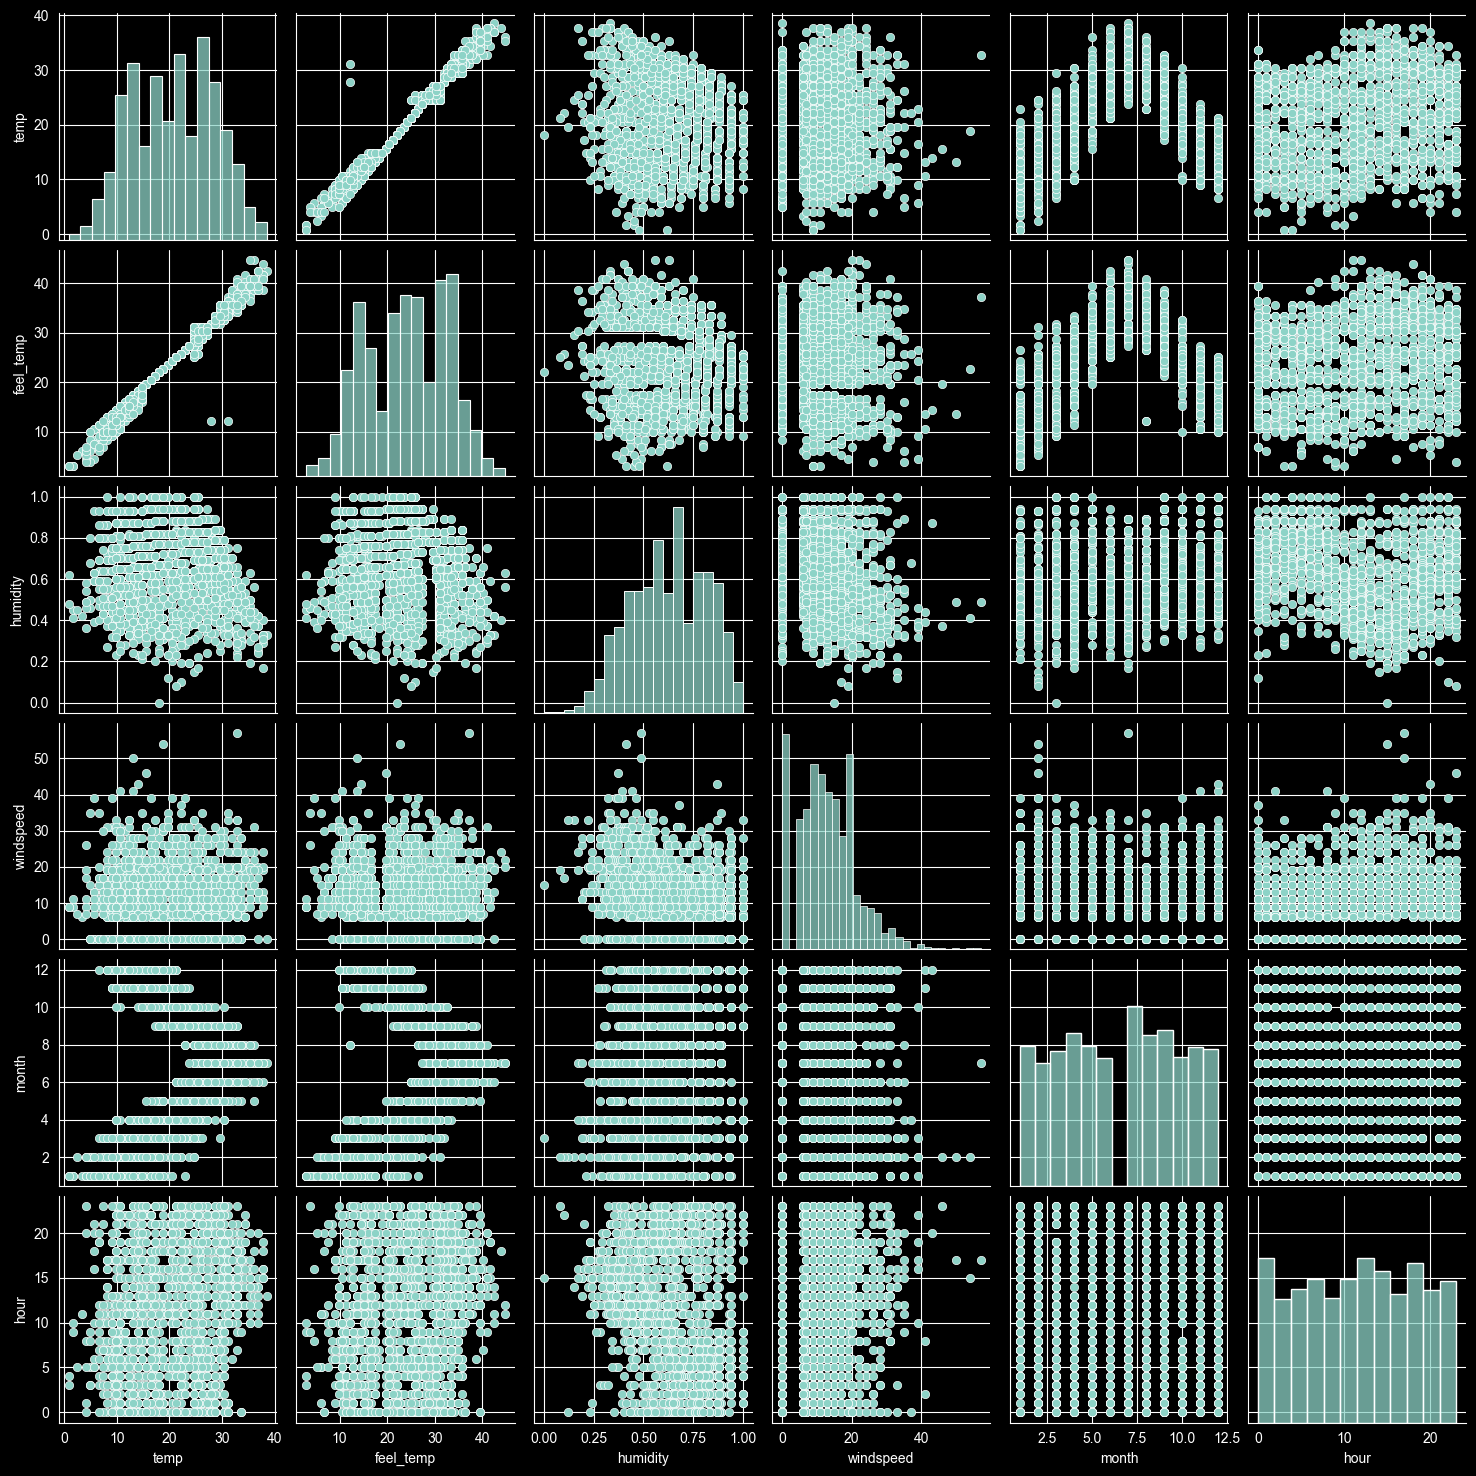

In [109]:
sns.pairplot(dftrain[NUM_COLS].sample(1500, random_state=42))

In [115]:
data = add_constant(dftrain[NUM_COLS].astype(float))

dfvif = pd.DataFrame({
    "zmienna": NUM_COLS,
    "VIF": [vif(data.values, i+1) for i, _ in enumerate(NUM_COLS)]
}).sort_values("VIF", ascending=False)

print(dfvif.round(1))

     zmienna   VIF
1  feel_temp  43.6
0       temp  43.5
2   humidity   1.2
3  windspeed   1.2
5       hour   1.1
4      month   1.1


In [116]:
NUM_COLS.remove('feel_temp')
REMOVED = ['feel_temp']

In [119]:
df = df.drop(columns=REMOVED)

In [117]:
data = add_constant(dftrain[NUM_COLS].astype(float))

dfvif = pd.DataFrame({
    "zmienna": NUM_COLS,
    "VIF": [vif(data.values, i+1) for i, _ in enumerate(NUM_COLS)]
}).sort_values("VIF", ascending=False)

print(dfvif.round(1))

     zmienna  VIF
1   humidity  1.2
2  windspeed  1.1
4       hour  1.1
3      month  1.1
0       temp  1.1


In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['total_count', 'stratify_count']),
    df['total_count'],
    test_size=0.2,
    random_state=42,
    stratify=df['stratify_count']
)

<Axes: >

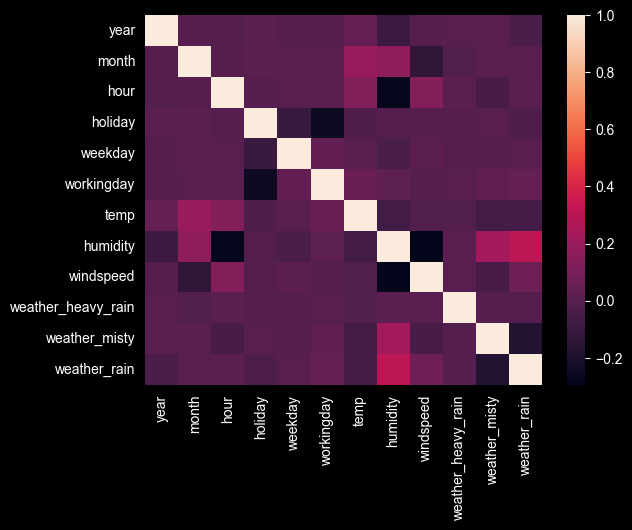

In [122]:
sns.heatmap(X_train.corr())

There is no more co linearity, so we can proceed with the analysis.
Now we look at distributions of features and goal variable.

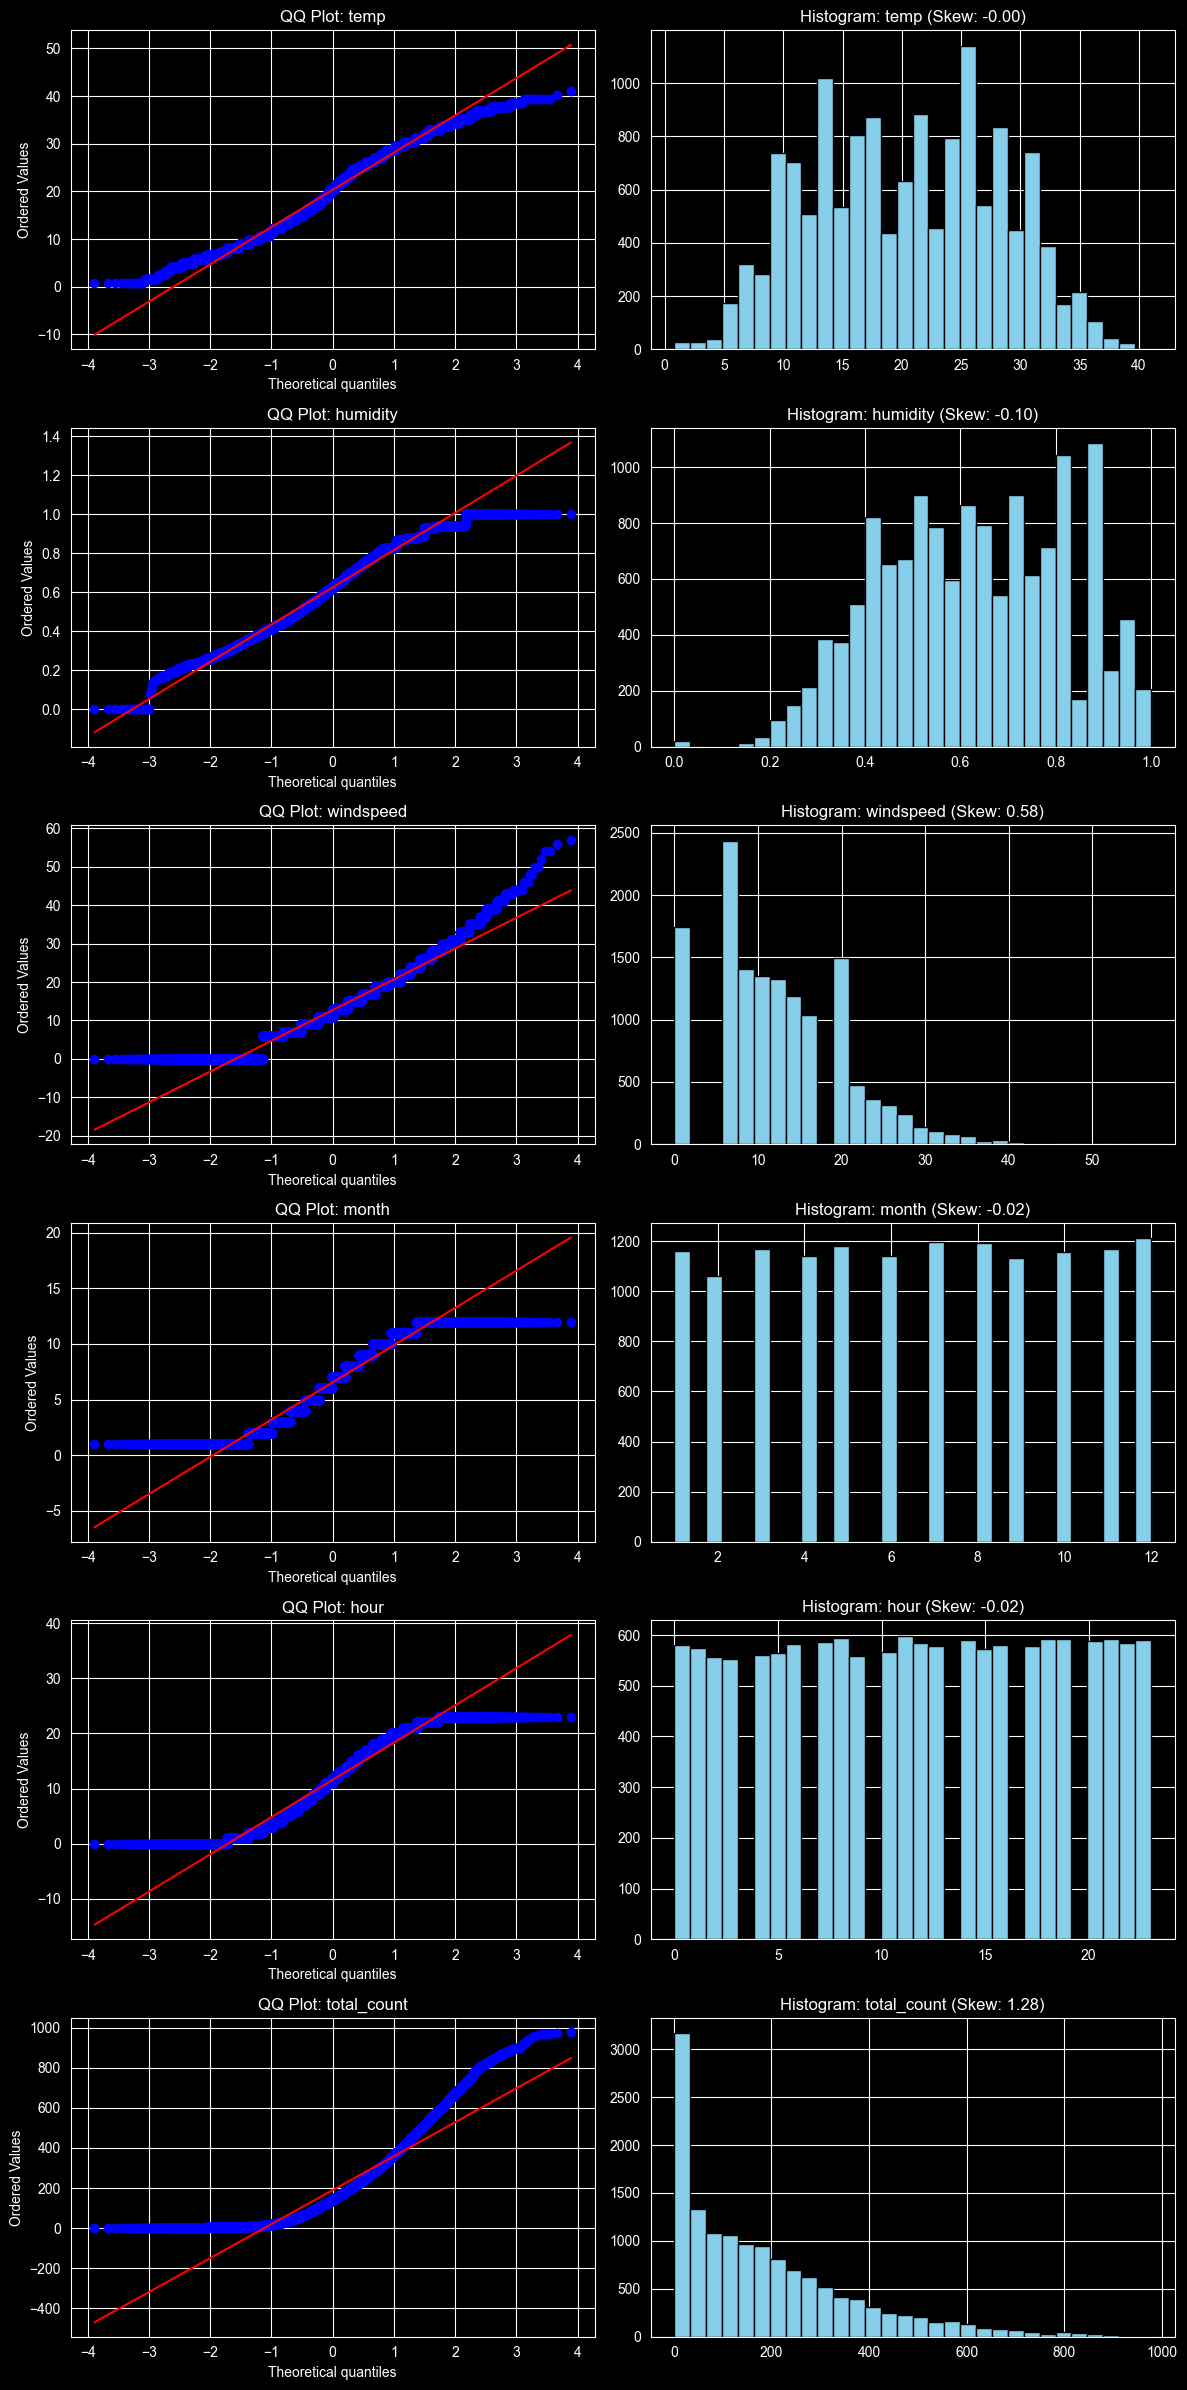

,Feature,Shapiro-Stat,p-value,Skewness
0,temp,0.977954,3.626857e-27,-0.002539
1,humidity,0.979657,3.479090e-26,-0.103664
2,windspeed,0.959664,3.691596e-35,0.575284
3,month,0.942043,1.786357e-40,-0.016068
4,hour,0.949569,2.177643e-38,-0.017889
5,total_count,0.873050,2.607744e-53,1.275562


In [133]:
analyze_normality(dftrain, columns=NUM_COLS + ['total_count'])

1. workingday, holiday, weather (after one hot encoding) are binary variables, so they stay as they are.
---
2. Temp, humidity, wind speed are right skewed, so we will apply Robust Scaler.
3. Month and hour has to be one hot encoded.
---
4. The target variable is right skewed, so we will apply log transformation to it.


In [ ]:
# 1

In [143]:
# 2, 3
num_features = ['temp', 'humidity', 'windspeed']
cat_features = ['month', 'hour', 'weekday']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

preprocessor.set_output(transform="pandas")

X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

In [145]:
import joblib
joblib.dump(preprocessor, '../models/preprocessor.joblib')

['../models/preprocessor.joblib']

In [146]:
# 4
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

Text(0.5, 1.0, 'QQ Plot: After Log1p')

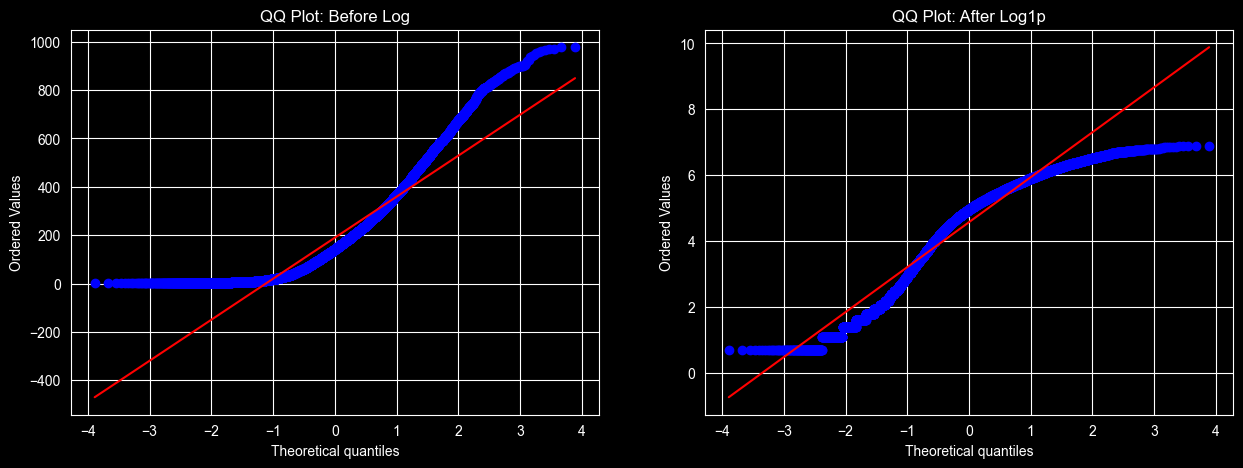

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

stats.probplot(y_train, dist="norm", plot=axes[0])
axes[0].set_title("QQ Plot: Before Log")

stats.probplot(y_train_log, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot: After Log1p")

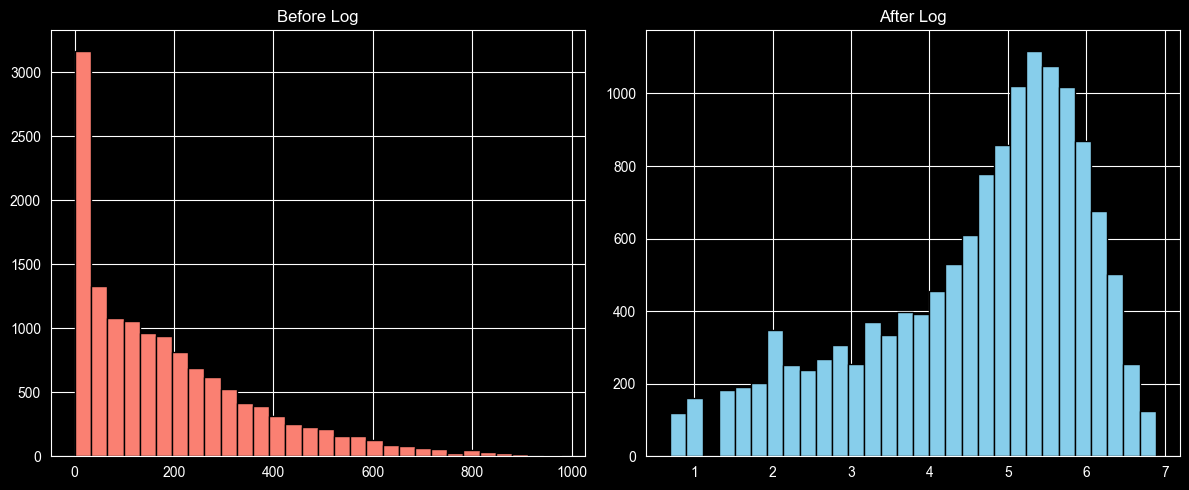

In [161]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(y_train, bins=30, color='salmon', edgecolor='black')
plt.title(f"Before Log")

plt.subplot(1, 2, 2)
plt.hist(y_train_log, bins=30, color='skyblue', edgecolor='black')
plt.title(f"After Log")
plt.tight_layout()
plt.show()

In [168]:
X_train_final.to_csv('../data/split/X_train.csv', index=False)
X_test_final.to_csv('../data/split/X_test.csv', index=False)
y_train_log.to_csv('../data/split/y_train.csv', index=False)
y_test_log.to_csv('../data/split/y_test.csv', index=False)